# MIMO_MTS test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.

### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
import numpy as np
from mimo_mts import MimoMtsOverlay
from mimo_mts.utils.plot import plot_adc_wfm, plot_adc_psd, plot_complex_wfm_stack

%load_ext autoreload
%autoreload 2

In [3]:
# reset PL to remove any cached .hwh file
from pynq import PL
PL.reset()

In [4]:
ol = MimoMtsOverlay(config='MIMO_ZCU208')

In [5]:
ol

< MimoMtsOverlay >:
{ 'bitfile_name': 'mimo_mts.bit',
  'board': 'ZCU208',
  'clk104_tcs': { 'lmk_tcs': 'designs/CLK104/LMK04828_499.64MHz_CLKin0_499.64MHz.tcs',
                  'lmxadc_tcs': 'designs/CLK104/LMX2594_4000MHz.tcs',
                  'lmxdac_tcs': 'designs/CLK104/LMX2594_4000MHz.tcs'}}
RFDC MTS Latency Report:
DAC Tile 0 Latency: 128, Offset: 16
DAC Tile 1 Latency: 128, Offset: 16
DAC Tile 2 Latency: 128, Offset: 16
DAC Tile 3 Latency: 128, Offset: 16
ADC Tile 0 Latency:  96, Offset: 0
ADC Tile 1 Latency:  96, Offset: 0
ADC Tile 2 Latency:  96, Offset: 0
ADC Tile 3 Latency:  96, Offset: 0

In [6]:
ol.clk104

< CLK104Config >:
  === LMK04828: ===
part            :    LMK04828B
SYSREF_FREQ     :        4.996 MHz
OSCout_FREQ     :      160.009 MHz
CLKin0_FREQ     :      499.640 MHz
CLKin1_FREQ     :       10.000 MHz
CLKin2_FREQ     :       76.800 MHz
CLKout0_FREQ    :      499.640 MHz
CLKout1_FREQ    :        4.996 MHz
CLKout2_FREQ    :      499.640 MHz
CLKout3_FREQ    :        4.996 MHz
CLKout4_FREQ    :      499.640 MHz
CLKout5_FREQ    :        4.996 MHz
CLKout6_FREQ    :      499.640 MHz
CLKout7_FREQ    :        4.996 MHz
CLKout8_FREQ    :      499.640 MHz
CLKout9_FREQ    :        4.996 MHz
CLKout10_FREQ   :      499.640 MHz
CLKout11_FREQ   :        4.996 MHz
CLKout12_FREQ   :      499.640 MHz
CLKout13_FREQ   :        4.996 MHz
CLKin_SEL_MODE  :       CLKin0
VCO_MUX         :         VCO0
  === LMX2594 ADC: ===
part            :      LMX2594
Fosc_FREQ       :      499.640 MHz
FoutA_FREQ      :     3997.120 MHz
FoutB_FREQ      :     3997.120 MHz
Fpd_FREQ        :      249.820 MHz
Fvco_FREQ 

# Configure trigger

internal, 1 Hz

In [7]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 0
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 0xfff

# Generate Waveforms for Loopback

This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
The DAC accepts a stream of interleave I/Q samples.

In [8]:
fs = ol.board.adc_sampling_rate
start = 1149 + 48 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9} ns')

RF loop back latency: 299.25 ns


In [9]:
t = np.arange(ol.dac_player.size) / fs
Fc = fs / 16 # 250 MHz
amp = 2**14 - 1
dac_wfm = np.exp(1j * 2 * np.pi * Fc * t) * amp
pulse_length_ns = 512  # short pulse
n_samples = int(pulse_length_ns / 1e9 * fs)
dac_wfm[n_samples:] = 0
dac_wfm = dac_wfm[::2]  # decimate by 2
dac_i = (dac_wfm.real).astype(np.int16)
dac_q = (dac_wfm.imag).astype(np.int16)

ol.write_dac_iq_buf(dac_i, dac_q)

In [10]:
ol.set_dac_mixer_dco(freq_mhz=0, phase=0)

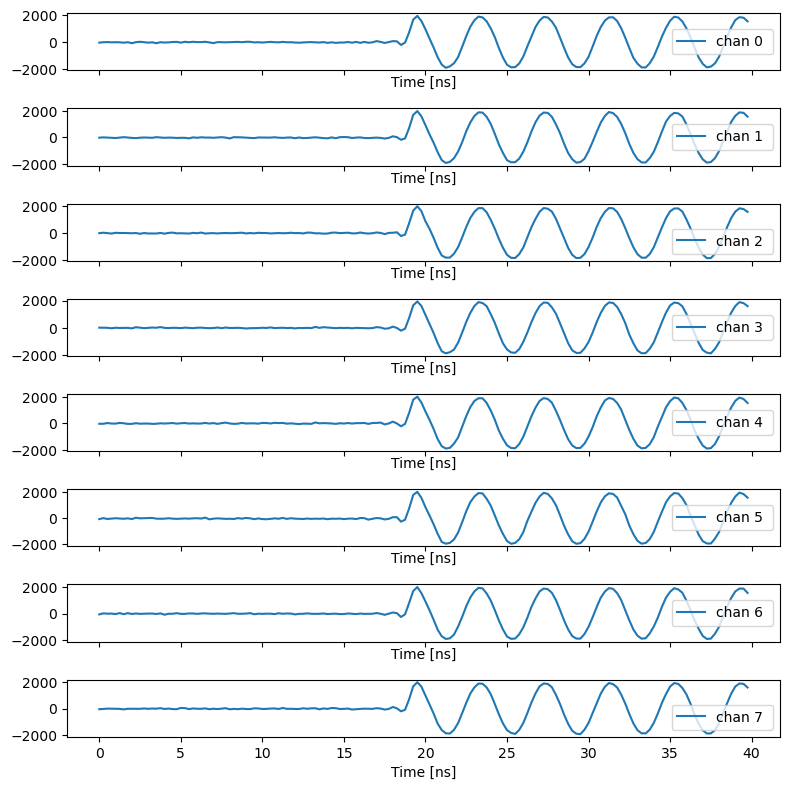

In [11]:
darray_i, darray_q = ol.capture_adc_iq_buf()
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

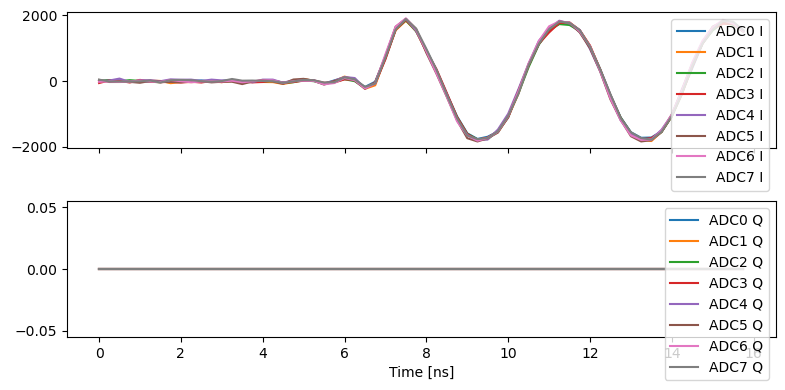

In [12]:
ol.set_adc_mixer_dco(phase=0)
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)

### Change mixer phase to 90 deg and check I/Q waveforms

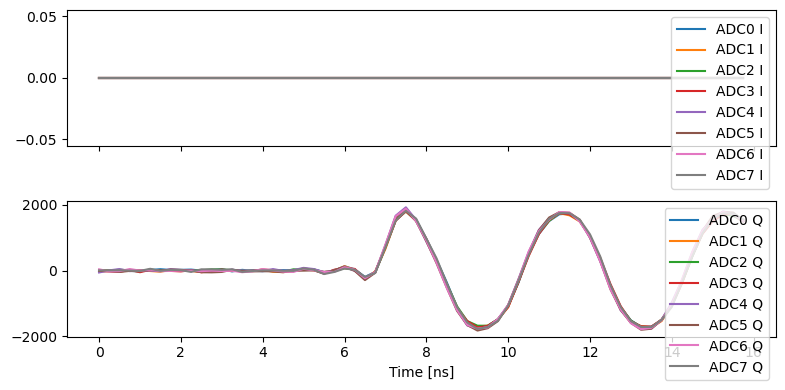

In [13]:
ol.set_adc_mixer_dco(phase=90)
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)

### Verify Alignment Stability

In [14]:
n_samples = 1024
for i in range(3):
    ol.capture_adc_iq_buf(darray_i, darray_q);
    x = darray_q[0, start:start+n_samples].astype(np.float32)  # adc0 Q
    y = darray_q[3, start:start+n_samples].astype(np.float32)  # adc3 Q
    x_corr = np.correlate(x, y, mode='full')
    lags = np.arange(-n_samples+1, n_samples)
    delay = lags[np.argmax(x_corr)]
    print(f'Iteration {i} : Cross-correlation delay = {delay} samples')
    assert delay == 0, 'Cross-correlation delay is not zero'

Iteration 0 : Cross-correlation delay = 0 samples
Iteration 1 : Cross-correlation delay = 0 samples
Iteration 2 : Cross-correlation delay = 0 samples


### Set DAC baseband waveform as DC, reset mixer

In [15]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)
ol.write_dac_iq_buf(dac_i, dac_q)

ol.set_dac_mixer_dco(0)
ol.set_adc_mixer_dco(0)

### Change DAC mixer setting with NCO to 125 MHz

In [16]:
ol.set_dac_mixer_dco(125)

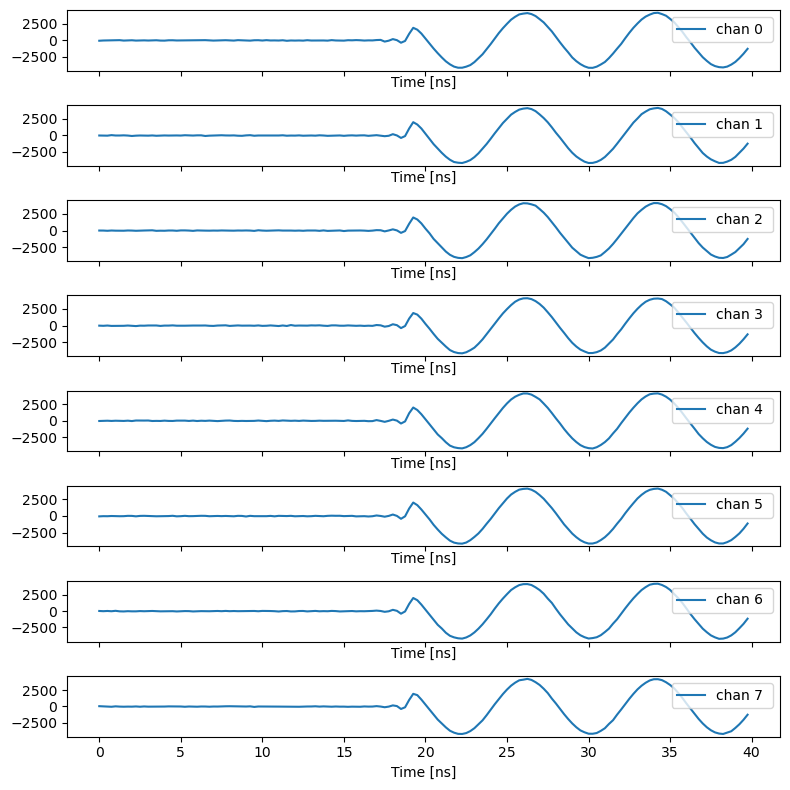

In [17]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

###  Change DAC mixer setting with NCO to 500 MHz

In [18]:
ol.set_dac_mixer_dco(500)

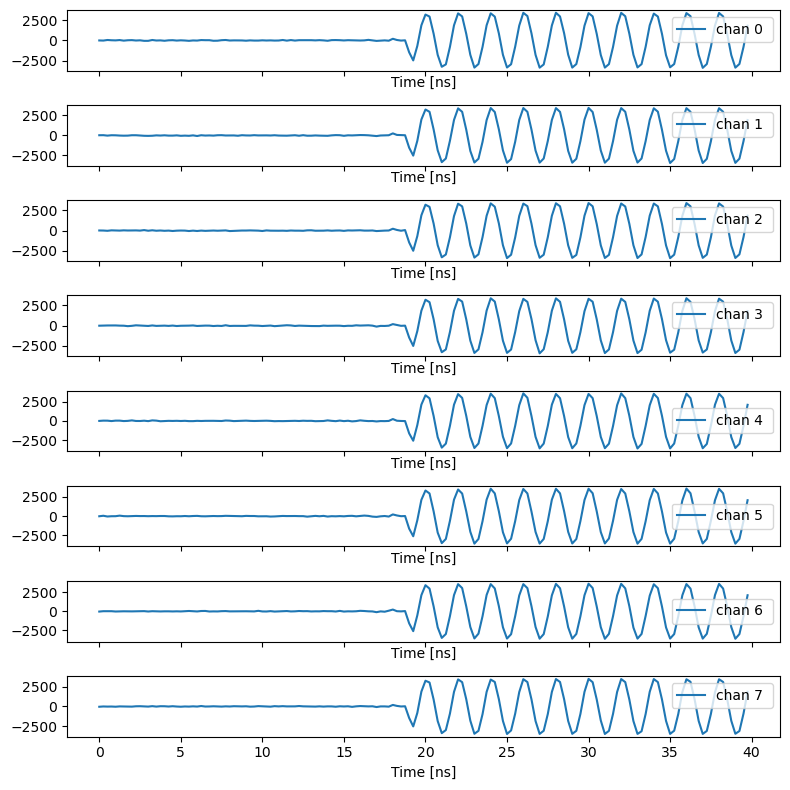

In [19]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80])